                                          image_path  \
0  segmented-images\images\0004a718-546c-41c2-9c6...   
1  segmented-images\images\0017b7c7-90f8-4de2-872...   
2  segmented-images\images\0048d8c5-b59d-461c-983...   
3  segmented-images\images\00f98835-8fd8-43fe-960...   
4  segmented-images\images\01503109-d81f-404e-a91...   

                                           mask_path    task  
0  segmented-images\masks\0004a718-546c-41c2-9c69...  polyps  
1  segmented-images\masks\0017b7c7-90f8-4de2-8723...  polyps  
2  segmented-images\masks\0048d8c5-b59d-461c-9834...  polyps  
3  segmented-images\masks\00f98835-8fd8-43fe-960d...  polyps  
4  segmented-images\masks\01503109-d81f-404e-a919...  polyps  


Computing Features:   0%|          | 0/1000 [00:00<?, ?it/s]


🏆 Medoid-1 Exemplar Selected 🏆
  Task: polyps
  Image Path: segmented-images\images\ca19617e-69a2-474c-bea8-9ccb2822c1fa.jpg
  Mask Path:  segmented-images\masks\ca19617e-69a2-474c-bea8-9ccb2822c1fa.jpg



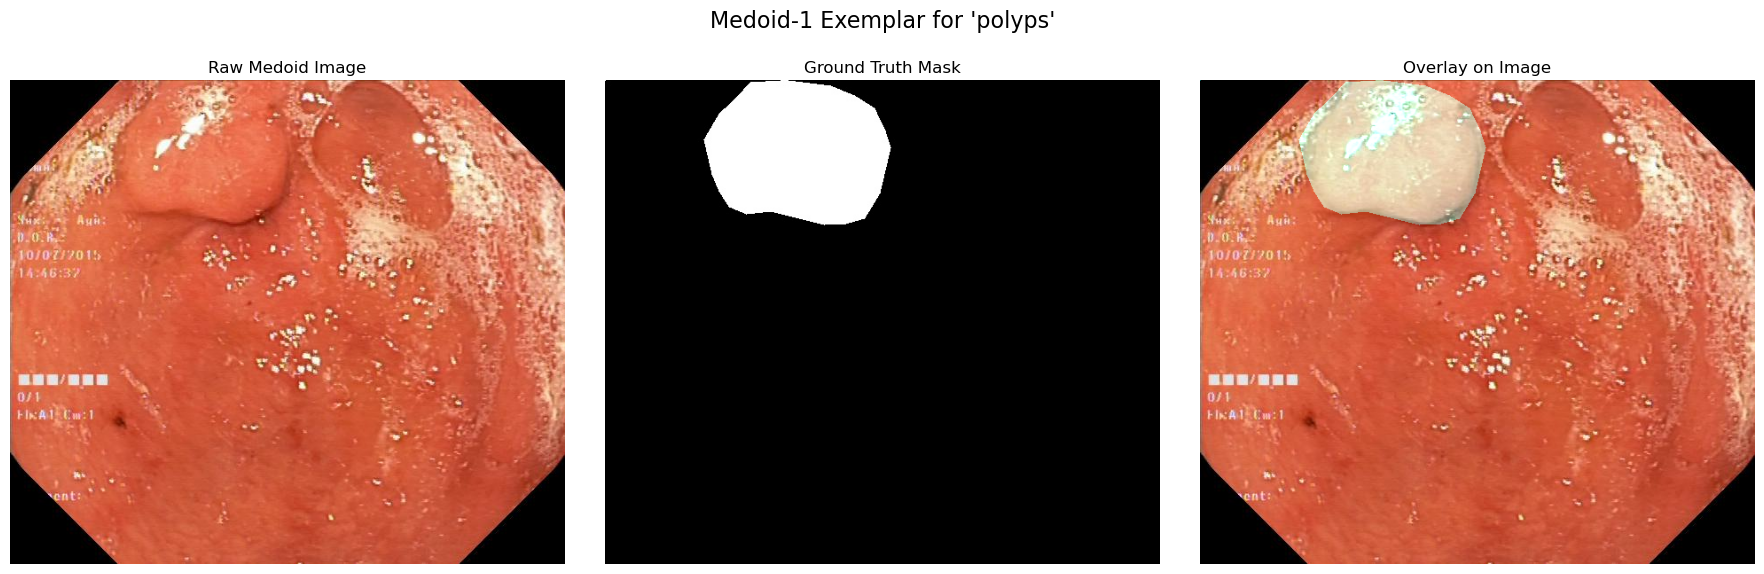

In [1]:
# %% [markdown]
"""
# Medoid-1 Exemplar Selection with Feature Caching

This notebook implements a self-contained, multithreaded pipeline to find the
Medoid-1 exemplar for a given medical image segmentation task. The Medoid-1 is
the single most representative sample in a dataset, defined as the image with
the minimum average feature distance to all other images.

**Workflow:**
1.  **Configuration**: All paths and parameters are set in a single dictionary.
2.  **Indexing**: The script scans the dataset directory to build a list of all
    image-mask pairs.
3.  **Feature Extraction & Caching**:
    - It first checks for a pre-computed feature cache (`.parquet` file).
    - If the cache exists, it's loaded instantly, saving significant time.
    - If not, it computes a suite of low-level image and mask features
      (histograms, HOG, shape statistics) in parallel using a thread pool.
    - The computed features are then saved to the cache for future runs.
4.  **Medoid Calculation**: The script uses the feature matrix to calculate the
    pairwise cosine distance between all images and identifies the medoid.
5.  **Verification & Output**: The selected medoid image, mask, and overlay are
    visualized, and its metadata is saved to a JSON manifest file for use in
    downstream few-shot prompting tasks.
"""

# %%
# =============================================================================
# Part 1: Setup & Configuration
# =============================================================================
import os
import sys
import json
import logging
import subprocess
import importlib.util
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from skimage import measure, filters, morphology
from skimage.feature import hog
from skimage.color import rgb2gray
from sklearn.preprocessing import normalize
from sklearn.metrics import pairwise_distances_chunked
from tqdm.auto import tqdm

# --- Ensure required packages are installed ---
def _ensure(pkg: str):
    """Ensures a specific version of a package is installed using pip."""
    logging.info("Verifying requirement: %s", pkg)
    # Pip is idempotent; it will not reinstall if the correct version is already present.
    # This command ensures the specific version is installed, resolving potential conflicts.
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

# Ensure necessary packages for image processing, data handling, and caching
# Pinning versions known to be stable together helps prevent runtime errors
# like the ArrowKeyError, which often stem from library version mismatches.
REQUIRED_PACKAGES = [
    "opencv-python==4.8.0.76",
    "scikit-image==0.22.0",
    "scikit-learn==1.3.2",
    "pandas==2.1.4",
    "pyarrow==14.0.1",
    "tqdm==4.66.1"
]
for pkg in REQUIRED_PACKAGES:
    _ensure(pkg)


# --- Logging Configuration ---
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.info("Starting Medoid-1 selection script.")

# --- Central Configuration ---
# All user-configurable parameters are in this dictionary.
CONFIG = {
    # Set the path to the root of your segmented image dataset.
    # It should contain 'images' and 'masks' subdirectories.
    "DATASET_DIR": "segmented-images",

    # Directory to save outputs (feature cache, final manifest).
    "OUTPUT_DIR": "outputs",

    # The specific task name to process. This should correspond to how you
    # conceptually group your data (e.g., 'polyps', 'dermoscopy').
    "TASK_NAME": "polyps",

    # Number of parallel threads for feature extraction.
    # Adjust based on your CPU cores (e.g., 8, 16).
    "NUM_WORKERS": 8,

    # Max side length for preprocessing to match benchmark protocol.
    "MAX_SIDE": 1024,
}

# --- Create output directories ---
output_dir = Path(CONFIG["OUTPUT_DIR"])
cache_dir = output_dir / "features"
exemplars_dir = output_dir / "exemplars"
cache_dir.mkdir(parents=True, exist_ok=True)
exemplars_dir.mkdir(parents=True, exist_ok=True)
logging.info("Output directories created/verified.")

# Define the full path for the feature cache file
CONFIG["CACHE_PATH"] = cache_dir / f"{Path(CONFIG['DATASET_DIR']).name}_features.parquet"
logging.info("Configuration loaded. Outputs will be saved in '%s'", output_dir)


# %%
# =============================================================================
# Part 2: Feature Engineering Functions (Self-Contained)
# =============================================================================

def resize_max_side(img, max_side=CONFIG["MAX_SIDE"]):
    """Resizes an image to a max side length while preserving aspect ratio."""
    h, w = img.shape[:2]
    s = max(h, w)
    if s <= max_side:
        return img
    scale = max_side / float(s)
    return cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)

def load_image_gray(path: str) -> np.ndarray:
    """Loads an image, resizes it, and converts to float64 grayscale [0, 1]."""
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Image not found at {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = resize_max_side(img) # Enforce max side for protocol consistency
    return rgb2gray(img)

def grayscale_hist(gray: np.ndarray, bins: int = 32) -> np.ndarray:
    """Computes a normalized grayscale intensity histogram."""
    hist, _ = np.histogram(gray.ravel(), bins=bins, range=(0.0, 1.0))
    hist = hist.astype(np.float64)
    hist /= (hist.sum() + 1e-8)
    return hist

def gradient_mag_hist(gray: np.ndarray, bins: int = 16) -> np.ndarray:
    """Computes a normalized Sobel gradient magnitude histogram."""
    gx = filters.sobel_h(gray)
    gy = filters.sobel_v(gray)
    mag = np.sqrt(gx**2 + gy**2)
    mag /= (mag.max() + 1e-8)
    hist, _ = np.histogram(mag.ravel(), bins=bins, range=(0.0, 1.0))
    hist = hist.astype(np.float64)
    hist /= (hist.sum() + 1e-8)
    return hist

def hog_descriptor(gray: np.ndarray) -> np.ndarray:
    """Computes Histogram of Oriented Gradients (HOG) features."""
    # Standardize image size for HOG to ensure fixed-length feature vectors
    hog_image = cv2.resize(gray, (256, 256))
    
    feat = hog(
        hog_image,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True,
    )
    return feat.astype(np.float32)

def mask_shape_features(mask: np.ndarray, gray: np.ndarray) -> np.ndarray:
    """Computes shape and boundary features from the largest connected component."""
    if mask.sum() == 0:
        return np.zeros(6, dtype=np.float32)

    lab = measure.label(mask, connectivity=1)
    props = measure.regionprops(lab)
    if not props:
        return np.zeros(6, dtype=np.float32)

    region = max(props, key=lambda p: p.area)
    area_frac = region.area / mask.size
    # Use Crofton perimeter for better rotation invariance
    perimeter = measure.perimeter_crofton(region.image, directions=4)
    per_over_sqrt_area = perimeter / (np.sqrt(region.area) + 1e-8)
    solidity = region.solidity if region.solidity is not None else 0.0
    ecc = region.eccentricity if region.eccentricity is not None else 0.0

    # Boundary contrast calculation
    boundary = morphology.dilation(region.image, morphology.square(3)) ^ region.image
    by, bx, _, _ = region.bbox
    full_boundary = np.zeros_like(mask, dtype=bool)
    h, w = region.image.shape
    full_boundary[by:by+h, bx:bx+w] = boundary

    gx = filters.sobel_h(gray)
    gy = filters.sobel_v(gray)
    mag = np.sqrt(gx**2 + gy**2)
    boundary_vals = mag[full_boundary]
    boundary_contrast = float(boundary_vals.mean()) if boundary_vals.size > 0 else 0.0

    return np.array([area_frac, per_over_sqrt_area, solidity, ecc, boundary_contrast, float(mask.sum())], dtype=np.float32)

def compute_all_features(image_path: str, mask_path: str) -> dict:
    """Master wrapper to compute and concatenate all features for one sample."""
    try:
        gray = load_image_gray(image_path)
        mask_raw = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask_raw is None:
            raise FileNotFoundError(f"Mask not found at {mask_path}")

        # Ensure mask matches resized image size for accurate feature calculation
        if mask_raw.shape != gray.shape:
            mask = cv2.resize(mask_raw, (gray.shape[1], gray.shape[0]),
                              interpolation=cv2.INTER_NEAREST)
        else:
            mask = mask_raw
        mask = (mask > 127).astype(np.uint8)

        gray_hist_feat = grayscale_hist(gray)
        grad_hist_feat = gradient_mag_hist(gray)
        hog_feat = hog_descriptor(gray)
        shape_feat = mask_shape_features(mask, gray)

        feature_vector = np.concatenate([
            gray_hist_feat,
            grad_hist_feat,
            hog_feat,
            shape_feat
        ]).astype(np.float32)

        return {
            "image_path": str(image_path),
            "mask_path": str(mask_path),
            "feature_vector": feature_vector,
            "status": "success"
        }
    except Exception as e:
        logging.warning("Failed to process %s: %s", image_path, e)
        return {
            "image_path": str(image_path),
            "mask_path": str(mask_path),
            "feature_vector": None,
            "status": "error"
        }

logging.info("Feature engineering functions defined.")


# %%
# =============================================================================
# Part 3: Dataset Indexing
# =============================================================================
logging.info("Starting dataset indexing...")
dataset_path = Path(CONFIG["DATASET_DIR"])
image_dir = dataset_path / "images"
mask_dir = dataset_path / "masks"

if not (dataset_path.is_dir() and image_dir.is_dir() and mask_dir.is_dir()):
    raise FileNotFoundError(
        f"Dataset not found or incomplete. Expected 'images/' & 'masks/' "
        f"subdirectories inside {dataset_path}."
    )

img_paths = sorted(image_dir.iterdir())
mask_map = {p.name: p for p in mask_dir.iterdir()}

# Create a list of dictionaries for the DataFrame
data_index = [
    {"image_path": str(img), "mask_path": str(mask_map[img.name])}
    for img in img_paths if img.name in mask_map
]

if not data_index:
    raise ValueError("No matching image-mask pairs found in the dataset directories.")

df_index = pd.DataFrame(data_index)
df_index["task"] = CONFIG["TASK_NAME"] # Assign the task name

logging.info("Found %d image-mask pairs for task '%s'.", len(df_index), CONFIG["TASK_NAME"])
print(df_index.head())


# %%
# =============================================================================
# Part 4: Feature Extraction with Caching Logic
# =============================================================================
logging.info("Initiating feature extraction or cache loading.")
cache_path = Path(CONFIG["CACHE_PATH"])
df_features = None

if cache_path.exists():
    logging.info("✅ Feature cache found. Loading from %s", cache_path)
    df_features = pd.read_parquet(cache_path)
    logging.info("Successfully loaded %d feature vectors from cache.", len(df_features))
else:
    logging.warning("⚠️ Feature cache not found. Starting one-time feature computation.")
    logging.info("Using %d worker threads. This may take a while...", CONFIG["NUM_WORKERS"])

    results = []
    with ThreadPoolExecutor(max_workers=CONFIG["NUM_WORKERS"]) as executor:
        # Create a list of jobs to submit
        jobs = [
            executor.submit(compute_all_features, row["image_path"], row["mask_path"])
            for _, row in df_index.iterrows()
        ]

        # Process jobs with a progress bar
        for future in tqdm(jobs, total=len(df_index), desc="Computing Features"):
            results.append(future.result())

    # Process results
    successful_results = [r for r in results if r["status"] == "success"]
    error_count = len(results) - len(successful_results)
    logging.info("Feature computation complete. %d successful, %d errors.", len(successful_results), error_count)

    if not successful_results:
        raise RuntimeError("Feature extraction failed for all images. Please check file paths and integrity.")

    # Create DataFrame from successful results
    df_features = pd.DataFrame(successful_results)
    df_features.drop(columns=['status'], inplace=True)

    # Convert numpy arrays to lists before saving to Parquet
    logging.info("Converting feature vectors to list format for caching.")
    df_features['feature_vector'] = df_features['feature_vector'].apply(list)

    # Save to cache for future runs
    logging.info("Saving features to cache at %s", cache_path)
    df_features.to_parquet(cache_path, index=False)
    logging.info("✅ Cache created successfully.")


# %%
# =============================================================================
# Part 5: Medoid Calculation
# =============================================================================
def find_medoid_idx(feature_vectors: np.ndarray, metric: str = "cosine") -> int:
    """
    Finds the medoid index using memory-efficient chunked distance calculation.
    
    1.  Performs row-wise L2 normalization, the standard preprocessing for cosine distance.
    2.  Uses pairwise_distances_chunked to compute row sums of the distance matrix
        without ever allocating the full N x N matrix in memory.
    """
    logging.info("Normalizing feature vectors for cosine distance calculation.")
    Xn = normalize(feature_vectors, norm='l2')

    logging.info("Calculating medoid using memory-efficient chunked method...")
    sums = []
    # The reduce_func sums the distances for each row in a chunk.
    for row_sums in pairwise_distances_chunked(
        Xn, metric=metric, reduce_func=lambda D, start: D.sum(axis=1)
    ):
        sums.append(row_sums)
    
    total_distances = np.concatenate(sums)
    return int(np.argmin(total_distances))

logging.info("Starting Medoid-1 selection for task: '%s'", CONFIG["TASK_NAME"])

df_task_features = df_features.copy()
logging.info("Processing %d samples for medoid selection.", len(df_task_features))

# Assemble the feature matrix
X = np.array(df_task_features['feature_vector'].tolist(), dtype=np.float32)
logging.info("Assembled feature matrix with shape: %s", X.shape)

# Find the medoid using the new, robust function
medoid_idx = find_medoid_idx(X, metric="cosine")
logging.info("Medoid found at index: %d", medoid_idx)


# %%
# =============================================================================
# Part 6: Verification and Final Output
# =============================================================================

# Retrieve the full record of the medoid
medoid_record = df_task_features.iloc[medoid_idx]

print("\n" + "="*50)
print("🏆 Medoid-1 Exemplar Selected 🏆")
print("="*50)
print(f"  Task: {CONFIG['TASK_NAME']}")
print(f"  Image Path: {medoid_record['image_path']}")
print(f"  Mask Path:  {medoid_record['mask_path']}")
print("="*50 + "\n")


# --- Visualize the selected medoid ---
logging.info("Generating visualization for the selected medoid...")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plt.suptitle(f"Medoid-1 Exemplar for '{CONFIG['TASK_NAME']}'", fontsize=16)

# 1. Raw Image
# We need to reload the image for visualization as the feature pipeline uses grayscale
raw_image = cv2.imread(medoid_record['image_path'])
raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
axes[0].imshow(raw_image)
axes[0].set_title("Raw Medoid Image")
axes[0].axis("off")

# 2. Ground Truth Mask
gt_mask = cv2.imread(medoid_record['mask_path'], cv2.IMREAD_GRAYSCALE)
axes[1].imshow(gt_mask, cmap='gray')
axes[1].set_title("Ground Truth Mask")
axes[1].axis("off")

# 3. Overlay
overlay_color = [0, 200, 200] # Teal
alpha = 0.5
blended_image = raw_image.copy()
color_layer = np.zeros_like(blended_image)
color_layer[gt_mask > 127] = overlay_color
blended_image = cv2.addWeighted(blended_image, 1.0, color_layer, alpha, 0)
axes[2].imshow(blended_image)
axes[2].set_title("Overlay on Image")
axes[2].axis("off")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- Save the exemplar manifest ---
manifest = {
    "k": 1,
    "policy": "Medoid-1",
    "exemplars": [
        {
            "task": CONFIG["TASK_NAME"],
            "image_path": medoid_record['image_path'],
            "mask_path": medoid_record['mask_path']
        }
    ]
}

manifest_path = exemplars_dir / "exemplars_medoid1.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

logging.info("✅ Medoid-1 manifest saved to: %s", manifest_path)
logging.info("Script finished successfully.")



2025-08-17 01:50:01 — INFO — Notebook start.
2025-08-17 01:50:01 — INFO — Installing python-dotenv (missing)
2025-08-17 01:50:03 — INFO — Installing Pillow (missing)
2025-08-17 01:50:06 — INFO — GenAI backend: Dev API
2025-08-17 01:50:06 — INFO — Hyper-Kvasir dataset found at D:\Projects\gemini_image_segmentation\segmented-images
2025-08-17 01:50:06 — INFO — Exemplar manifest found at outputs\exemplars\exemplars_medoid1.json
2025-08-17 01:50:06 — INFO — 1000 paired images collected for querying.
2025-08-17 01:50:06 — INFO — Loaded Medoid-1 exemplar: ca19617e-69a2-474c-bea8-9ccb2822c1fa.jpg
2025-08-17 01:50:06 — INFO — Creating two-panel composite exemplar for one-shot prompt.
C:\Users\steal\AppData\Local\Temp\ipykernel_43584\861945078.py:222: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  colored_mask_layer_pil = Image.fromarray(colored_mask_layer_np, 'RGBA')


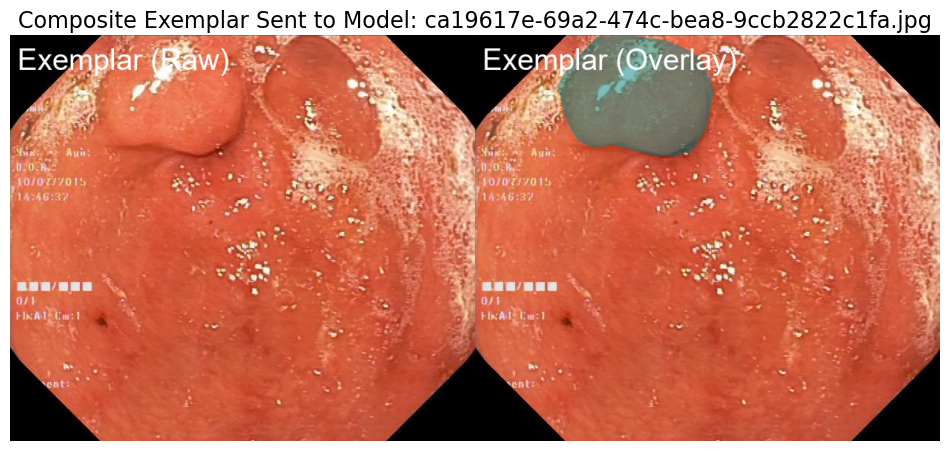

2025-08-17 01:50:06 — INFO — Selected query image: 70f5b2dc-80b0-432c-adc4-a6d6a4dba3cd.jpg
2025-08-17 01:50:06 — INFO — Workflow: Explicit caching DISABLED. Sending full one-shot prompt.
2025-08-17 01:50:06 — INFO — Starting Gemini API call without explicit caching.
2025-08-17 01:50:06 — INFO — AFC is enabled with max remote calls: 10.
2025-08-17 01:50:08 — INFO — HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
2025-08-17 01:50:08 — INFO — AFC remote call 1 is done.
2025-08-17 01:50:08 — INFO — Found 1 segmentation masks.


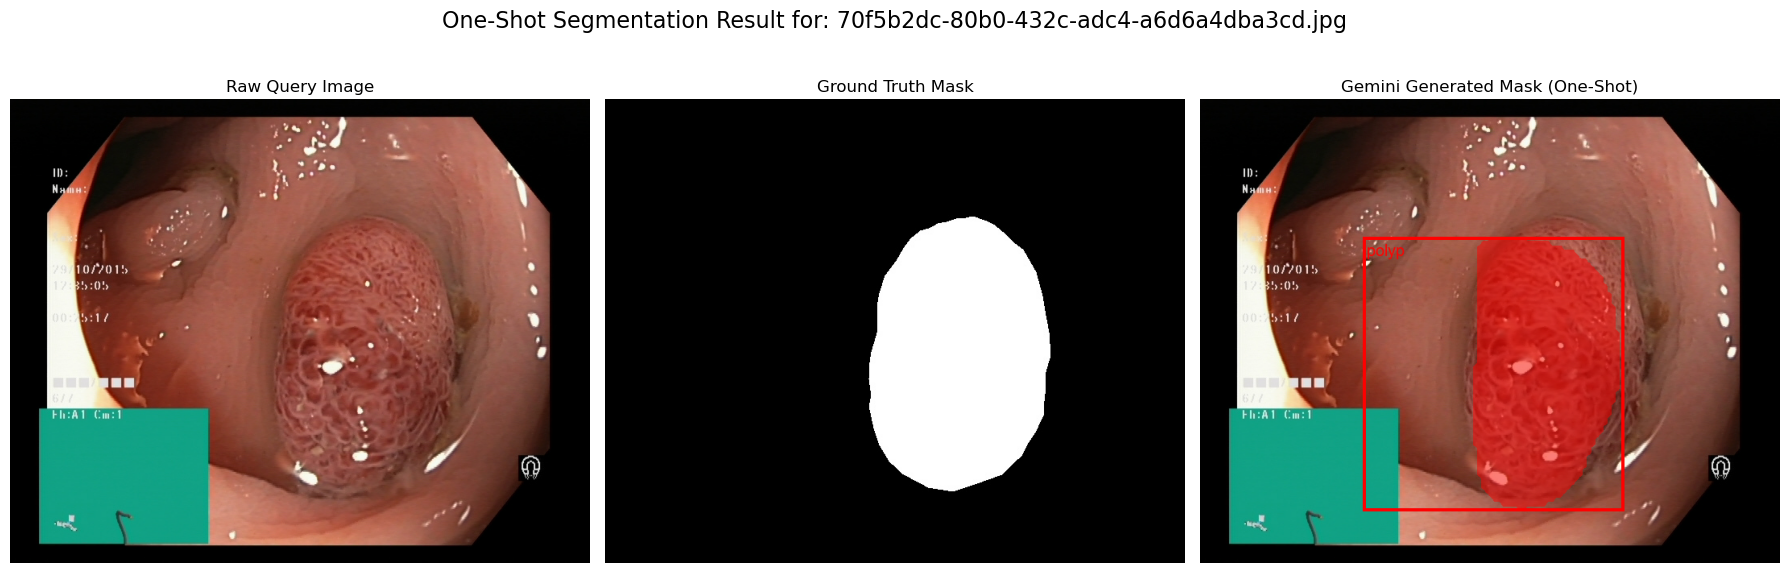

'\n✅ Environment verified, one-shot exemplar loaded, context cached, and Gemini smoke-test executed.\nThe script now correctly demonstrates the one-shot segmentation workflow.\n'

In [1]:
# %% [markdown]
"""
# 02 One-Shot Smoke Test · GenAI SDK edition (uses `environment.yml`)

*Last sync 17 Aug 2025* This script has been **adapted** from the zero-shot
benchmark to perform a **one-shot segmentation smoke test** using Gemini's
context caching feature.

**New Workflow:**
1.  **Load Exemplar**: Reads the `exemplars_medoid1.json` manifest to find the
    path to the pre-selected Medoid-1 exemplar image.
2.  **Create Composite Exemplar**: Generates a two-panel image showing the raw
    exemplar and the exemplar with a teal mask overlay. This composite is
    what the model will see.
3.  **Select Query Image**: Chooses a new, random image from the dataset to act
    as the test case.
4.  **One-Shot Inference**: Calls the Gemini API using the composite exemplar.
5.  **Parse & Visualize**: Displays the composite exemplar, then shows the
    segmentation result on the query image.

**Changelog (One-Shot Adaptation)**
* **ADDED** a text overlay to the composite exemplar image, clearly labeling
  the "Raw" and "Overlay" panels for the model.
* **UPDATED** the `EXEMPLAR_PROMPT` to be more explicit, stating the example
  shows a "perfect segmentation" and mentioning the "teal" color.
"""

# %%
# ---------- Preamble
import sys, logging, os, subprocess, importlib, json, io, random, base64, dataclasses
from datetime import datetime
from pathlib import Path
from typing import Tuple

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageColor, UnidentifiedImageError

assert sys.version_info >= (3, 11), (
    f"Python 3.11+ required, found {sys.version.split()[0]}")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.info("Notebook start.")

# %%
# ---------- Configuration ---
# NEW: Set this to True to use explicit caching, which may fail if the
# exemplar image + prompt is too small. False is the robust default.
USE_EXPLICIT_CACHING = False

# %%
# ---------- Ensure helper packages

def _ensure(pkg: str):
    """Checks if a package is installed and installs it if not."""
    if importlib.util.find_spec(pkg) is None:
        logging.info("Installing %s (missing)", pkg)
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

for extra in ("python-dotenv", "tqdm", "matplotlib", "numpy", "Pillow"):
    _ensure(extra)

# %%
# ---------- GenAI client
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=False)

from google import genai
from google.genai.types import (
    GenerateContentConfig, Part, ThinkingConfig, CachedContent,
    CreateCachedContentConfig, Content
)


if not os.getenv("GOOGLE_API_KEY"):
    raise ValueError("GOOGLE_API_KEY not found. Ensure it is in your .env file.")

# Initialize the client directly, as in the original script.
client = genai.Client()
logging.info("GenAI backend: %s", "Vertex" if client.vertexai else "Dev API")

# %%
# ---------- Dataset and Exemplar Paths
hk_dir = Path(os.getenv("HK_SEG_DIR", "segmented-images")).expanduser().resolve()
if not (hk_dir.is_dir() and (hk_dir / "images").is_dir() and (hk_dir / "masks").is_dir()):
    logging.error("Dataset not found or incomplete at the specified path.")
    raise FileNotFoundError(
        f"Expected 'images/' & 'masks/' subdirectories inside {hk_dir}. "
        "Please set the HK_SEG_DIR environment variable correctly."
    )
logging.info("Hyper-Kvasir dataset found at %s", hk_dir)

# --- NEW: Path to the exemplar manifest ---
EXEMPLAR_MANIFEST_PATH = Path("outputs/exemplars/exemplars_medoid1.json")
if not EXEMPLAR_MANIFEST_PATH.is_file():
    logging.error("Exemplar manifest not found at the specified path.")
    raise FileNotFoundError(
        f"Expected to find '{EXEMPLAR_MANIFEST_PATH}'. "
        "Please run the medoid selection script first."
    )
logging.info("Exemplar manifest found at %s", EXEMPLAR_MANIFEST_PATH)


# %%
# ---------- Collect Query Images & Load Exemplar
img_paths = sorted((hk_dir / "images").iterdir())
mask_map  = {p.name: p for p in (hk_dir / "masks").iterdir()}

dataset = [(img, mask_map[img.name]) for img in img_paths if img.name in mask_map]
assert dataset, "No image-mask pairs found in the dataset!"
logging.info("%d paired images collected for querying.", len(dataset))

# --- NEW: Load the exemplar record ---
with open(EXEMPLAR_MANIFEST_PATH, "r") as f:
    manifest = json.load(f)
    exemplar_record = manifest["exemplars"][0]
    exemplar_img_path = Path(exemplar_record["image_path"])
    exemplar_mask_path = Path(exemplar_record["mask_path"])

logging.info("Loaded Medoid-1 exemplar: %s", exemplar_img_path.name)
exemplar_image_raw = Image.open(exemplar_img_path)
exemplar_mask_raw = Image.open(exemplar_mask_path)


# %%
# ---------- Segmentation Utils (No Changes)

@dataclasses.dataclass(frozen=True)
class SegmentationMask:
    """A dataclass to hold a single segmentation mask's data."""
    y0: int
    x0: int
    y1: int
    x1: int
    mask: np.ndarray # Full-size mask [img_height, img_width] with values 0..255
    label: str

def parse_json(json_output: str) -> str:
    """Cleans the model's JSON output by removing markdown fencing."""
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line.strip() == "```json":
            json_content = "\n".join(lines[i+1:])
            closing_fence_index = json_content.find("```")
            if closing_fence_index != -1:
                json_content = json_content[:closing_fence_index]
            return json_content.strip()
    return json_output.strip()

def parse_segmentation_masks(
    predicted_str: str, *, img_height: int, img_width: int
) -> list[SegmentationMask]:
    """Parses the model's JSON output into a list of SegmentationMask objects."""
    cleaned_json = parse_json(predicted_str)
    if not cleaned_json:
        logging.warning("Parsing model output resulted in an empty string.")
        return []

    try:
        items = json.loads(cleaned_json)
    except json.JSONDecodeError as e:
        logging.error(f"Failed to decode JSON: {e}")
        logging.error(f"Problematic string after cleaning: {cleaned_json}")
        return []

    masks = []
    for item in items:
        try:
            abs_y0 = int(item["box_2d"][0] / 1000 * img_height)
            abs_x0 = int(item["box_2d"][1] / 1000 * img_width)
            abs_y1 = int(item["box_2d"][2] / 1000 * img_height)
            abs_x1 = int(item["box_2d"][3] / 1000 * img_width)

            if abs_y0 >= abs_y1 or abs_x0 >= abs_x1:
                logging.warning("Skipping item with invalid bounding box: %s", item["box_2d"])
                continue

            label = item["label"]
            png_b64_str = item["mask"]

            if not png_b64_str.startswith("data:image/png;base64,"):
                logging.warning("Skipping item with invalid mask format for label '%s'", label)
                continue

            png_bytes = base64.b64decode(png_b64_str.removeprefix("data:image/png;base64,"))
            partial_mask_img = Image.open(io.BytesIO(png_bytes))

            bbox_height = abs_y1 - abs_y0
            bbox_width = abs_x1 - abs_x0
            if bbox_height < 1 or bbox_width < 1:
                logging.warning("Skipping item with zero-area bounding box for label '%s'", label)
                continue

            resized_mask = partial_mask_img.resize((bbox_width, bbox_height), resample=Image.Resampling.BILINEAR)
            full_mask_np = np.zeros((img_height, img_width), dtype=np.uint8)
            full_mask_np[abs_y0:abs_y1, abs_x0:abs_x1] = np.array(resized_mask)

            masks.append(SegmentationMask(abs_y0, abs_x0, abs_y1, abs_x1, full_mask_np, label))
        except (KeyError, IndexError, TypeError, base64.binascii.Error, UnidentifiedImageError) as e:
            logging.error(f"Skipping malformed item in JSON response: {item}. Error: {e}")
            continue
    return masks

def overlay_mask_on_img(img: Image.Image, mask: np.ndarray, color: str, alpha: float = 0.5) -> Image.Image:
    """Overlays a single mask onto a PIL Image."""
    color_rgb = ImageColor.getrgb(color)
    img_rgba = img.convert("RGBA")
    overlay_color_rgba = color_rgb + (int(alpha * 255),)

    colored_mask_layer_np = np.zeros((img.height, img.width, 4), dtype=np.uint8)
    
    # Ensure mask is a 2D boolean array to prevent IndexError
    mask_binary = mask > 127
    if mask_binary.ndim == 3:
        mask_binary = mask_binary[..., 0] # Take first channel if it's 3D

    colored_mask_layer_np[mask_binary] = overlay_color_rgba
    colored_mask_layer_pil = Image.fromarray(colored_mask_layer_np, 'RGBA')

    return Image.alpha_composite(img_rgba, colored_mask_layer_pil)

def plot_segmentation_masks(img: Image.Image, segmentation_masks: list[SegmentationMask]) -> Image.Image:
    """Draws all masks, bounding boxes, and labels on an image."""
    if not segmentation_masks:
        return img.convert("RGB")

    colors = ["red", "green", "blue", "yellow", "purple", "orange", "cyan", "magenta"]
    try:
        font = ImageFont.truetype("arial.ttf", size=20)
    except IOError:
        logging.warning("Arial font not found, using default. Labels may be small.")
        font = ImageFont.load_default()

    img_with_masks = img.copy()
    for i, seg_mask in enumerate(segmentation_masks):
        color = colors[i % len(colors)]
        img_with_masks = overlay_mask_on_img(img_with_masks, seg_mask.mask, color)

    draw = ImageDraw.Draw(img_with_masks)
    for i, seg_mask in enumerate(segmentation_masks):
        color = colors[i % len(colors)]
        box = ((seg_mask.x0, seg_mask.y0), (seg_mask.x1, seg_mask.y1))
        draw.rectangle(box, outline=color, width=4)
        if seg_mask.label:
            text_position = (seg_mask.x0 + 5, seg_mask.y0 + 5)
            draw.text(text_position, seg_mask.label, fill=color, font=font)

    return img_with_masks.convert("RGB")


# %%
# ---------- Gemini One-Shot Functions (Adapted)

MODEL_NAME = "gemini-2.5-flash"
# UPDATED: Prompt is now more explicit about the exemplar's quality and format.
EXEMPLAR_PROMPT = (
    'Task: Segment the colorectal polyp in the query image.\n\n'
    'Guidance: The following two-panel image is a perfect example. The left panel is the original image, '
    'and the right panel shows the target (polyp) with a perfect teal segmentation mask. '
    'Use this to guide your segmentation policy (what to include/exclude).\n\n'
    'Output: Return JSON only. For each mask, include keys "box_2d", "mask", and "label". '
    'Use the label "polyp". Do not include any text outside the JSON.'
)

# --- Function for explicit caching workflow ---
def create_cached_exemplar_context(composite_exemplar_image: Image.Image) -> str:
    """
    Uploads the composite exemplar image and prompt to create a reusable cache
    and returns the cache name (string).
    """
    logging.info("Creating cached context for the one-shot exemplar...")

    with io.BytesIO() as img_byte_arr:
        composite_exemplar_image.save(img_byte_arr, format='JPEG')
        img_bytes = img_byte_arr.getvalue()

    cache = client.caches.create(
        model=f"models/{MODEL_NAME}",
        config=CreateCachedContentConfig(
            system_instruction=EXEMPLAR_PROMPT,
            contents=[
                Content(role="user", parts=[Part.from_bytes(data=img_bytes, mime_type="image/jpeg")])
            ],
            display_name="kvasir-medoid1-cache",
            ttl="3600s",
        ),
    )
    logging.info("✅ Cached context created successfully. Handle: %s", cache.name)
    return cache.name


def gemini_seg_with_cache(
    query_image_obj: Image.Image, cache_name: str
) -> Tuple[list[SegmentationMask], float]:
    """
    Sends a query PIL Image to Gemini using a cache name and returns a list of masks.
    """
    logging.info("Starting Gemini API call with cache: %s", cache_name)
    original_width, original_height = query_image_obj.size

    try:
        img_for_api = query_image_obj.copy()
        max_dim = 1024
        if img_for_api.height > max_dim or img_for_api.width > max_dim:
            img_for_api.thumbnail((max_dim, max_dim))
        
        with io.BytesIO() as img_byte_arr:
            img_for_api.save(img_byte_arr, format='JPEG')
            img_bytes = img_byte_arr.getvalue()

        final_instruction_prompt = "Based on the provided example, segment the colorectal polyp in this new image."
        
        gen_config = GenerateContentConfig(
            cached_content=cache_name,
            thinking_config=ThinkingConfig(thinking_budget=0),
            temperature=0.5
        )

        query_image_part = Part.from_bytes(data=img_bytes, mime_type='image/jpeg')
        final_text_part = Part(text=final_instruction_prompt)

        contents = [query_image_part, final_text_part]

        start_time = datetime.now()
        response = client.models.generate_content(
            model=MODEL_NAME, contents=contents, config=gen_config
        )
        latency = (datetime.now() - start_time).total_seconds()
        
        masks = parse_segmentation_masks(
            response.text, img_height=original_height, img_width=original_width
        )
        logging.info("Found %d segmentation masks.", len(masks))
        return masks, latency

    except Exception as e:
        logging.error("An error occurred during gemini_seg_with_cache.", exc_info=True)
        return [], 0.0

# --- NEW: Function for non-caching workflow ---
def gemini_seg_without_cache(
    composite_exemplar_image: Image.Image, query_image_obj: Image.Image
) -> Tuple[list[SegmentationMask], float]:
    """
    Sends the full one-shot prompt (composite exemplar + query) in a single call.
    """
    logging.info("Starting Gemini API call without explicit caching.")
    original_width, original_height = query_image_obj.size

    try:
        # 1. Prepare composite exemplar image
        with io.BytesIO() as img_byte_arr:
            composite_exemplar_image.save(img_byte_arr, format='JPEG')
            exemplar_bytes = img_byte_arr.getvalue()

        # 2. Prepare query image
        img_for_api = query_image_obj.copy()
        max_dim = 1024
        if img_for_api.height > max_dim or img_for_api.width > max_dim:
            img_for_api.thumbnail((max_dim, max_dim))
        with io.BytesIO() as img_byte_arr:
            img_for_api.save(img_byte_arr, format='JPEG')
            query_bytes = img_byte_arr.getvalue()
        
        # 3. Define the final instruction
        final_instruction_prompt = "Based on the provided example, segment the colorectal polyp in this new image."

        # 4. Construct the full multi-part contents
        contents = [
            Part(text=EXEMPLAR_PROMPT),
            Part.from_bytes(data=exemplar_bytes, mime_type="image/jpeg"),
            Part.from_bytes(data=query_bytes, mime_type="image/jpeg"),
            Part(text=final_instruction_prompt)
        ]

        # 5. Define generation config (without caching)
        gen_config = GenerateContentConfig(
            thinking_config=ThinkingConfig(thinking_budget=0),
            temperature=0.5
        )

        # 6. Send the request
        start_time = datetime.now()
        response = client.models.generate_content(
            model=MODEL_NAME, contents=contents, config=gen_config
        )
        latency = (datetime.now() - start_time).total_seconds()
        
        masks = parse_segmentation_masks(
            response.text, img_height=original_height, img_width=original_width
        )
        logging.info("Found %d segmentation masks.", len(masks))
        return masks, latency

    except Exception as e:
        logging.error("An error occurred during gemini_seg_without_cache.", exc_info=True)
        return [], 0.0

# %%
# ---------- Main Execution and Visualization (Adapted for One-Shot) ----------

# --- NEW: Create the composite exemplar for the model ---
logging.info("Creating two-panel composite exemplar for one-shot prompt.")
# FIX: Convert mask to single-channel grayscale ('L') before making numpy array
exemplar_mask_np = np.array(exemplar_mask_raw.convert("L"))
# Create the overlay image
overlay_image = overlay_mask_on_img(exemplar_image_raw, exemplar_mask_np, color="teal", alpha=0.5)

# Stack raw image and overlay side-by-side
raw_np = np.array(exemplar_image_raw.convert("RGB"))
overlay_np = np.array(overlay_image.convert("RGB"))
composite_np = np.hstack((raw_np, overlay_np))
composite_exemplar_image = Image.fromarray(composite_np)

# --- NEW: Add text overlay to the composite image ---
draw = ImageDraw.Draw(composite_exemplar_image)
try:
    font = ImageFont.truetype("arial.ttf", size=40)
except IOError:
    logging.warning("Arial font not found, using default for exemplar labels.")
    font = ImageFont.load_default()

# Add text to the left and right panels
panel_width = exemplar_image_raw.width
draw.text((10, 10), "Exemplar (Raw)", fill="white", font=font)
draw.text((panel_width + 10, 10), "Exemplar (Overlay)", fill="white", font=font)


# --- Visualize the composite exemplar that will be sent to the model ---
plt.figure(figsize=(12, 6))
plt.imshow(composite_exemplar_image)
plt.title(f"Composite Exemplar Sent to Model: {exemplar_img_path.name}", fontsize=16)
plt.axis("off")
plt.show()


# Select a random query sample and open the image
query_img_path, query_mask_path = random.choice(dataset)
# Ensure the query image is not the same as the exemplar
while query_img_path == exemplar_img_path:
    query_img_path, query_mask_path = random.choice(dataset)
logging.info("Selected query image: %s", query_img_path.name)
query_image = Image.open(query_img_path)


if USE_EXPLICIT_CACHING:
    logging.info("Workflow: Using EXPLICIT context caching.")
    cached_exemplar_name = None
    try:
        # 1. Create the cached context using the COMPOSITE image
        cached_exemplar_name = create_cached_exemplar_context(composite_exemplar_image)
        # 2. Execute segmentation using the cache
        gemini_masks, _ = gemini_seg_with_cache(query_image, cached_exemplar_name)
    finally:
        # 3. Clean up the cache if it was created
        if cached_exemplar_name:
            try:
                client.caches.delete(name=cached_exemplar_name)
                logging.info("✅ Successfully deleted cached content: %s", cached_exemplar_name)
            except Exception as e:
                logging.warning("Could not delete cached content. It will expire automatically. Error: %s", e)
else:
    logging.info("Workflow: Explicit caching DISABLED. Sending full one-shot prompt.")
    # Execute segmentation by sending the COMPOSITE image in the call
    gemini_masks, _ = gemini_seg_without_cache(composite_exemplar_image, query_image)


# Visualize the results for the QUERY image
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f"One-Shot Segmentation Result for: {query_img_path.name}", fontsize=16)

# Plot 1: Query Image
ax[0].imshow(query_image)
ax[0].set_title("Raw Query Image")
ax[0].axis("off")

# Plot 2: Ground Truth Mask for the Query Image
try:
    ax[1].imshow(Image.open(query_mask_path))
    ax[1].set_title("Ground Truth Mask")
except FileNotFoundError:
    ax[1].text(0.5, 0.5, 'Mask Not Found', ha='center', va='center')
    ax[1].set_title("Ground truth mask (not found)")
ax[1].axis("off")

# Plot 3: Gemini Generated Mask for the Query Image
if gemini_masks:
    composite_image = plot_segmentation_masks(query_image, gemini_masks)
    ax[2].imshow(composite_image)
    ax[2].set_title("Gemini Generated Mask (One-Shot)")
else:
    ax[2].imshow(query_image)
    ax[2].text(0.5, 0.5, 'Mask Generation Failed', ha='center', va='center', color='red',
               bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5'))
    ax[2].set_title("Gemini (failed)")
ax[2].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# %% [markdown]
"""
✅ Environment verified, one-shot exemplar loaded, context cached, and Gemini smoke-test executed.
The script now correctly demonstrates the one-shot segmentation workflow.
"""
